**Import Depencies**

In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report)

**2. Load Dataset**

In [60]:
#load the dataset to a pandas dataframe
creditcard_data = pd.read_csv('/creditcard.csv')

**3. Data Analysis**

In [61]:
creditcard_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [62]:
creditcard_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [63]:
creditcard_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [64]:
creditcard_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [65]:
# Distribution of Legit and Fraudulent Transactions.
creditcard_data['Class'].value_counts()

,count
Class,
0,284315
1,492


This dataset is highly imbalanced. There are two class value 0 and 1.
* 0 --> Legit Transaction
* 1 --> Fraudulent Transaction

In [66]:
# Separating the data for Analysis.
legit = creditcard_data[creditcard_data.Class == 0]
fraud = creditcard_data[creditcard_data.Class == 1]

In [67]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [68]:
# Statistical measures of the data
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [69]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [70]:
# Compares the value for both transaction. (legit and fraudulent)
creditcard_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Using under-sampling method, Build a sample dataset containing similar distribution of Normal(or Legit) Transaction and Fraudulent Transaction.

In [71]:
# Number of Fraudulent Transaction = 492
legit_sample = legit.sample(n=492)

Now Concatenating the Two DataFrame

In [72]:
new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [73]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
155180,104721.0,-0.689470,0.756077,2.300403,-0.854517,0.549473,0.108987,0.604418,-0.121096,1.275484,...,-0.265454,-0.369829,-0.359468,-0.493440,0.408367,-0.866042,-0.107109,-0.166114,9.39,0
174473,121927.0,-2.804924,-1.762025,-0.650618,0.514883,1.079407,2.969557,3.047468,-2.029841,2.572401,...,-1.017017,0.305645,-0.037936,-0.913534,-2.676387,-1.595357,-2.618238,0.684646,401.85,0
11206,19428.0,1.162126,0.226919,0.721283,0.712460,-0.312326,-0.281348,-0.246074,0.019170,1.139814,...,-0.321712,-0.713494,0.197295,0.142114,0.044605,0.057494,-0.046658,-0.000119,1.98,0
190317,128782.0,2.079286,-0.005002,-2.032459,-0.024342,0.354048,-1.508465,0.608366,-0.379957,0.139402,...,0.194141,0.622446,-0.018536,0.040610,0.338080,0.225582,-0.094702,-0.092041,0.77,0
105108,69366.0,1.263546,0.303807,0.056578,1.002585,-0.039365,-0.662560,0.203668,-0.188055,0.053927,...,-0.004739,0.003520,-0.170924,-0.146454,0.747825,-0.295330,0.009697,0.016074,13.90,0


In [74]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [75]:
new_dataset['Class'].value_counts()

,count
Class,
0,492
1,492


In [76]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,96680.296748,0.017057,0.019951,-0.028289,-0.007492,0.042024,0.071061,0.009503,-0.061338,0.043738,...,0.000655,0.001540,-0.005889,-0.054226,0.024459,-0.003622,-0.005211,0.019893,-0.016209,93.152805
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


**4. HANDLE IMBALANCED DATA USING SMOTE**

In [93]:
from imblearn.over_sampling import SMOTE

Splitting the data into FEATURES and TARGETS.

In [94]:
X = new_dataset.drop(columns= 'Class', axis=1)
Y = new_dataset['Class']

In [78]:
print(X)

            Time        V1        V2        V3        V4        V5        V6  \
155180  104721.0 -0.689470  0.756077  2.300403 -0.854517  0.549473  0.108987   
174473  121927.0 -2.804924 -1.762025 -0.650618  0.514883  1.079407  2.969557   
11206    19428.0  1.162126  0.226919  0.721283  0.712460 -0.312326 -0.281348   
190317  128782.0  2.079286 -0.005002 -2.032459 -0.024342  0.354048 -1.508465   
105108   69366.0  1.263546  0.303807  0.056578  1.002585 -0.039365 -0.662560   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

In [79]:
print(Y)

155180    0
174473    0
11206     0
190317    0
105108    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


Next, Splitting the data into Training data and Testing data.

In [80]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,
stratify=Y,random_state=2)

In [81]:
print(X.shape, X_train.shape, X_test.shape)

(984, 30) (787, 30) (197, 30)


Apply SMOTE

In [95]:
smote = SMOTE(random_state=42)

X_train_resampled, Y_train_resampled = smote.fit_resample(
X_train, Y_train)

print(Y_train_resampled.value_counts())

Class
1    394
0    394
Name: count, dtype: int64


In [97]:
X_train_resampled
Y_train_resampled

,Class
0,1
1,0
2,0
3,0
4,0
...,...
783,0
784,1
785,1
786,0


**5. MODEL TRAINING**
- FEATURE SCALING
- LOGISTICS REGRESSION

In [98]:
model = LogisticRegression(max_iter=10000)

In [99]:
# SCALE RESAMPLED DATA
scaler = StandardScaler()

X_train_resampled_scaled = scaler.fit_transform(
X_train_resampled
)

X_test_scaled = scaler.transform(X_test)


In [100]:
# Training the Logistic Regression Model with training model
model.fit(X_train_resampled, Y_train_resampled)

LogisticRegression(max_iter=10000)

**6. PREDICTION**

In [101]:
y_pred = model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**7. MODEL EVALUATION**
- Accuracy Score
- Classification Report
- Confusion Matrix

In [102]:
print("Accuracy Score:")
print(accuracy_score(Y_test, y_pred))

Accuracy Score:
0.7309644670050761


In [103]:
print("Classification Report:")
print(classification_report(Y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        99
           1       1.00      0.46      0.63        98

    accuracy                           0.73       197
   macro avg       0.83      0.73      0.71       197
weighted avg       0.82      0.73      0.71       197



In [104]:
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))

Confusion Matrix:
[[99  0]
 [53 45]]


RANDOM FOREST

In [105]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
n_estimators=100,
random_state=42
)

In [106]:
rf_model.fit(
X_train_resampled,
Y_train_resampled
)

RandomForestClassifier(random_state=42)

In [107]:
rf_pred = rf_model.predict(X_test)

In [110]:
print("Random Forest Results")
print(classification_report(Y_test, rf_pred))

Random Forest Results
              precision    recall  f1-score   support

           0       0.87      0.97      0.92        99
           1       0.97      0.86      0.91        98

    accuracy                           0.91       197
   macro avg       0.92      0.91      0.91       197
weighted avg       0.92      0.91      0.91       197



XGBOOST

In [111]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
n_estimators=100,
learning_rate=0.1,
max_depth=6,
random_state=42
)

In [112]:
xgb_model.fit(
X_train_resampled,
Y_train_resampled
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [113]:
print("XGBoost Results")
print(classification_report(Y_test, xgb_pred))

XGBoost Results
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        99
           1       0.96      0.87      0.91        98

    accuracy                           0.91       197
   macro avg       0.92      0.91      0.91       197
weighted avg       0.92      0.91      0.91       197



**8. VISUALIZATION**

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

sns.set_style("whitegrid")

***CLASS DISTRIBUTION***

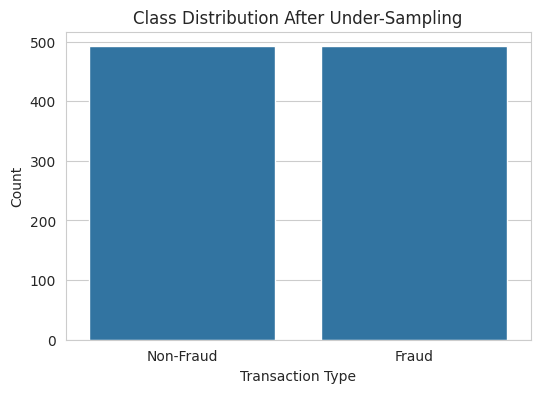

In [130]:
plt.figure(figsize=(6,4))

sns.countplot(x=new_dataset['Class'])

plt.title("Class Distribution After Under-Sampling")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.xticks([0,1], ['Non-Fraud', 'Fraud'])

plt.savefig(
    "class_distribution_after_under-sampling.png",
    dpi=300,
    bbox_inches='tight')

plt.show()

***CLASS DISTRIBUTION AFTER SMOTE***

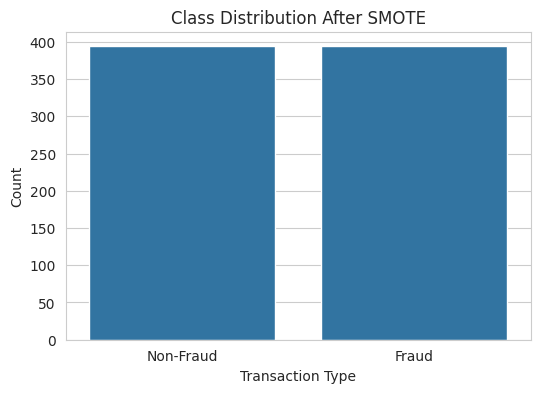

In [131]:
plt.figure(figsize=(6,4))

sns.countplot(x=Y_train_resampled)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.xticks([0,1], ['Non-Fraud', 'Fraud'])

plt.savefig(
    "class_distribution_after_SMOTE.png",
    dpi=300,
    bbox_inches='tight')

plt.show()

***CONFUSION MATRIX***

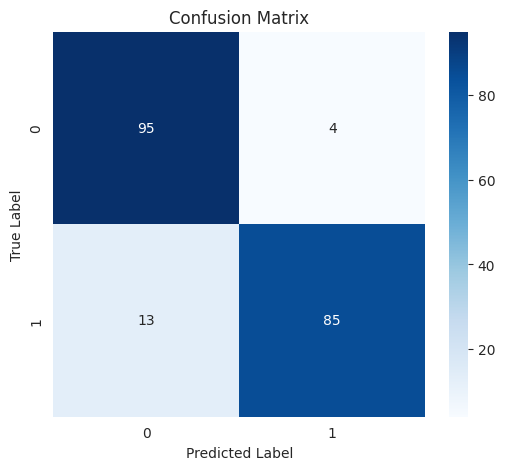

In [129]:
cm = confusion_matrix(Y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight')

plt.show()

***ROC CURVE***

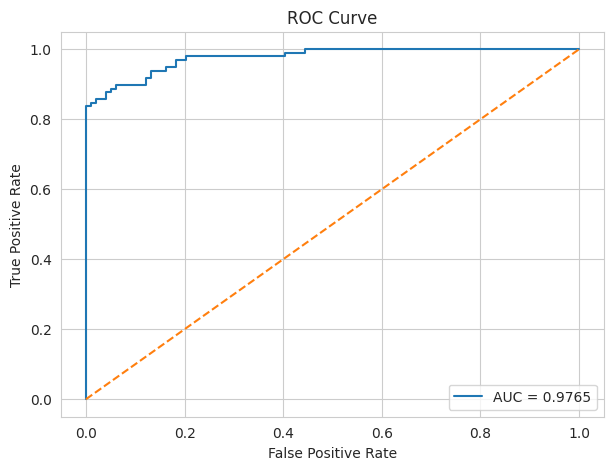

In [132]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr,
tpr,
label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig(
    "ROC_curve.png",
    dpi=300,
    bbox_inches='tight')

plt.show()

***PRECISION-RECALL CURVE***

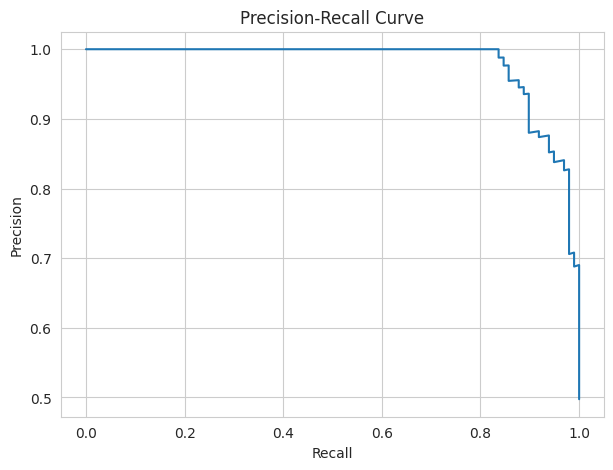

In [133]:
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)
plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.savefig(
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches='tight')

plt.show()

***FEATURE IMPORTANCE (XGBOOST)***

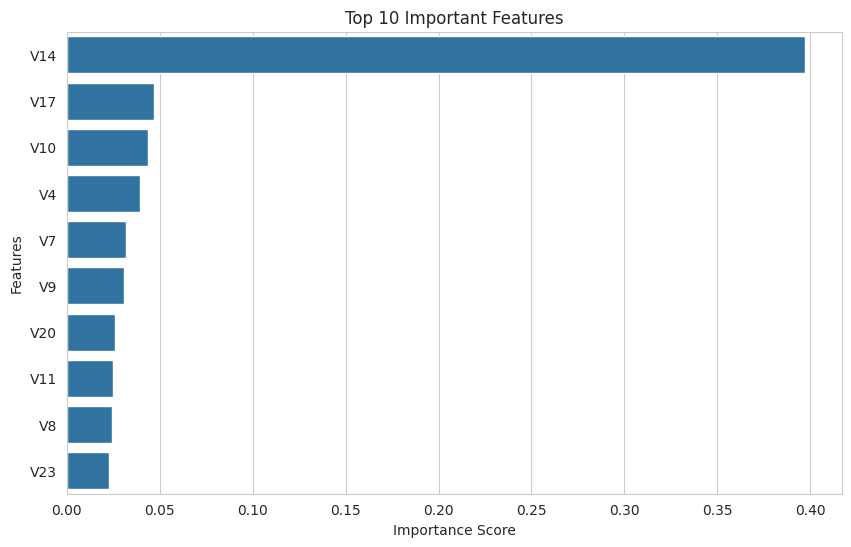

In [134]:
feature_importance = pd.DataFrame({
'Feature': X.columns,
'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
data=feature_importance.head(10),
x='Importance',
y='Feature'
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.savefig(
    "important_features.png",
    dpi=300,
    bbox_inches='tight')

plt.show()

**9. MODEL COMPARISON TABLE**

In [136]:
results = pd.DataFrame({
'Model': [
'Logistic Regression',
'Random Forest',
'XGBoost'
],
'Accuracy': [
    accuracy_score(Y_test, y_pred),
    accuracy_score(Y_test, rf_pred),
    accuracy_score(Y_test, xgb_pred)
],

'F1 Score': [
    f1_score(Y_test, y_pred),
    f1_score(Y_test, rf_pred),
    f1_score(Y_test, xgb_pred)
]

})

In [137]:
print(results)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.730964  0.629371
1        Random Forest  0.913706  0.908108
2              XGBoost  0.913706  0.909091


***10. Save Best Model***

In [138]:
import pickle

pickle.dump(
xgb_model,
open('fraud_detection_model.pkl', 'wb')
)
